In [310]:
import sys
sys.path.append("../../src/")
from common_imports import *
from scipy.integrate import solve_ivp
from numpy import conj
from numpy import linalg as la
import kibble_zurek as kz
from time import time
#Load Pauli Matrices
s3,s1,s2 = array([[1,0],[0,-1]],dtype=complex),array([[0, 1],[1,0]],dtype=complex), array([[0,-1j],[1j,0]],dtype=complex)

In [ ]:
#Time Dependent g
def g(t,tau,alpha=1):
    return 1 - np.sign(t)*abs(t/tau)**(alpha)
#TFIM functions
def a(q,g):
    return g+ cos(q)
def b(q,g):
    return sin(q)
def w(q,g):
    return sqrt(g*g+2*g*cos(q)+1)
def BdG(q,g):
    return -2*(a(q,g)*s3+b(q,g)*s2)
#Time Evolution
def BdG_Evolution(t,U,tau,q,alpha=1):
    return -1j*BdG(q,g(t,tau,alpha))@U
def BdG_stationary_evolve(t,U,tau,q,alpha=1):
    return -1j*BdG(q,g(tau,tau,alpha))@U

def landau_states(tau,L,ts=0):
    if ts==0:
        t0 = -tau
        tf = tau
    else:
        t0,tf = ts 
    #Initialize Momenta
    n = np.arange(0,L//2)
    k = (2*n+1)*pi/L
    t_eval = np.linspace(t0, tf, 1000)

    #Empty Vectors
    us = []
    vs=  []
    #Time evolve each mode indepdently 
    for q in k:
        V0 = la.eigh(BdG(q,g(t0,tau)))[1][:,1]
        sol= solve_ivp(BdG_Evolution,
                [t0,tf],
                V0,
                args=(tau,q),
                t_eval=t_eval,method="DOP853", 
                rtol=1e-10,
                atol=1e-12,
                max_step=0.01)

        u = sol.y[0]
        v = sol.y[1]
        us.append(u)
        vs.append(v)
    #Generate a series of states:
    us = array(us)
    vs = array(vs)
    states = []
    for i, ti in enumerate(t_eval):
        state = [us[:,i],vs[:,i],k]
        states.append(state)
    return states,t_eval

    

In [ ]:
from joblib import Parallel, delayed

def evolve_mode(q, t0, tau, t_eval,alpha=1):
    V0 = la.eigh(BdG(q, g(t0, tau,alpha)))[1][:, 1]
    sol = solve_ivp(
        BdG_Evolution,
        [t0, tau],
        V0,
        args=(tau, q,alpha),
        t_eval=t_eval,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
        max_step=0.05,
    )
    return sol.y[0], sol.y[1]

def landau_states(tau, L,alpha=1,ts=0):
    if ts==0:
        t0 = -tau
        tf = tau
    else:
        t0,tf = ts 
    n = np.arange(0, L // 2)
    k = (2 * n + 1) * pi / L
    t_eval = np.linspace(t0, tf, 3000)

    results = Parallel(n_jobs=-1, prefer="processes")(
        delayed(evolve_mode)(q, t0, tau, t_eval,alpha) for q in k
    )

    us, vs = map(np.array, zip(*results))

    states = [[us[:, i], vs[:, i], k] for i in range(len(t_eval))]
    return states, t_eval


In [402]:
alpha =4/4
ns = np.arange(1,14)
xis = np.linspace(4,20,10)
taus = xis**((alpha+1)/alpha)


In [403]:
Pdifl = []
Pdifkz = []
defects1=[]
defects2=[]
t0 = time()
for tau in tqdm(taus):
    L = 300
    landaustates,t = landau_states(tau,L,alpha)
    kzstate = kz.state(L,tau,tau)
    fs = landaustates[-1]
    defects1.append(1-kz.sigma_general([0,1],fs))
    defects2.append(1-kz.sigma_general([0,1],kzstate))
    Pdifl.append([-log(kz.P_n(n+1,fs)/kz.P_n(n,fs)) for n in ns]  )
    Pdifkz.append([-log(kz.P_n(n+1,kzstate)/kz.P_n(n,kzstate)) for n in ns]  )
print(time()-t0)


100%|██████████| 10/10 [03:07<00:00, 18.73s/it]

187.3087351322174


[]

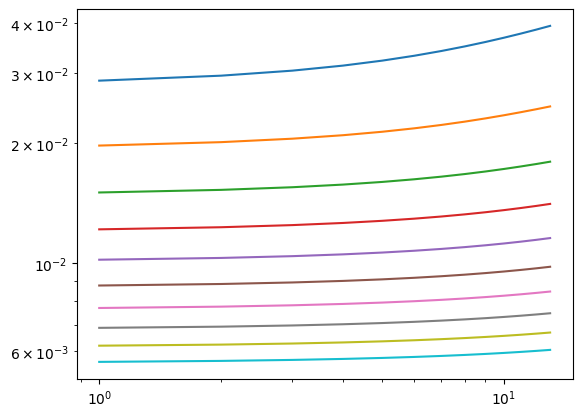

In [404]:
for p,t in zip(Pdifkz,taus):
    xi = sqrt(t)
    plot(ns,p)
loglog()

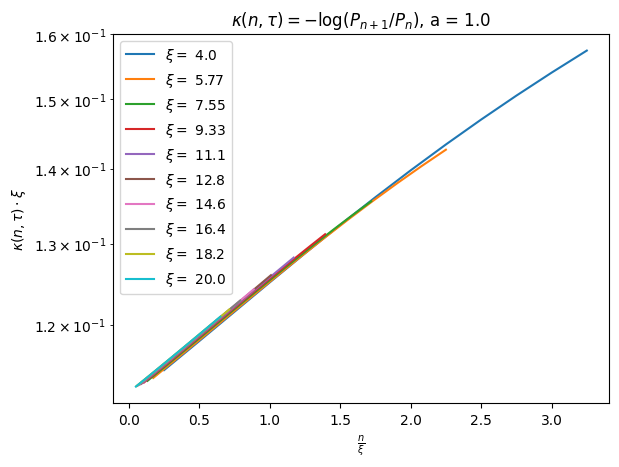

In [405]:
for t,pkz,p,xi in zip(taus,Pdifkz,Pdifl,xis):
   # xi = t**(alpha/(alpha+1))
    #xi=1
    plot(ns/xi,array(p)*xi,label=fr"$\xi= $ {str(xi)[:4]}")
    #scatter(ns/xi,array(pkz)*xi,label=rf"$\xi={str(xi)[:5]}$")
legend()
title(r"$\kappa(n,\tau) = -\log( P_{n+1}/P_{n})$, a = "+f"{alpha}")
xlabel(r"$\frac{n}{\xi}$")
ylabel(r"$\kappa(n,\tau) \cdot \xi$")
yscale("log")
savefig(f"alpha_{alpha}.png")

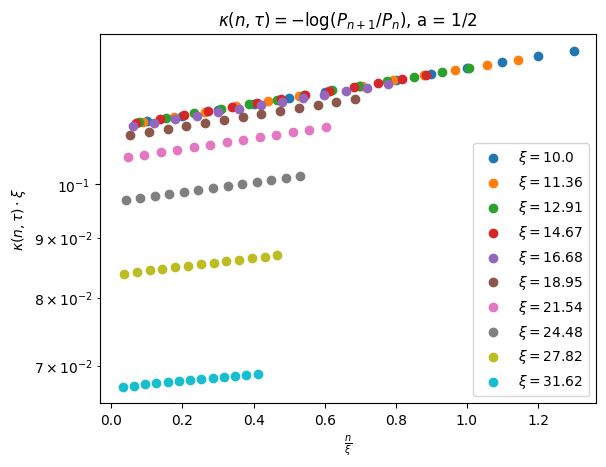

In [346]:
alpha= 1
for t,pkz,p in zip(taus,Pdifkz,Pdifl):
    xi = t**(alpha/(alpha+1))
    #xi=1
    #plot(ns/xi,array(p)*xi)
    scatter(ns/xi,array(pkz)*xi,label=rf"$\xi={str(xi)[:5]}$")
legend()
title(r"$\kappa(n,\tau) = -\log( P_{n+1}/P_{n})$, a = 1/2")
xlabel(r"$\frac{n}{\xi}$")
ylabel(r"$\kappa(n,\tau) \cdot \xi$")
yscale("log")